In [16]:
import numpy as np
import torch 
import random
import os

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # For multi-GPU
    
    # Force the use of deterministic algorithms
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # For PyTorch 2.x+ (Handles scatter/gather ops)
    torch.use_deterministic_algorithms(True)
    
    # Crucial for GNNs: some scatter operations need an extra flag
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8" 

seed_everything(42)

In [17]:
import pandas as pd 
from graph_constructor import smiles_to_graph

In [18]:
data = pd.read_csv("BBBP.csv")
data.shape

(2050, 4)

In [19]:
graphs = [] 

for i in range(data.shape[0]): 
  
  try: 
    graphs.append(smiles_to_graph(data['smiles'][i], data['p_np'][i]))
  
  except Exception as e: 
    # print(data.iloc[i, :])
    pass 

[15:55:17] Explicit valence for atom # 1 N, 4, is greater than permitted
[15:55:17] WARNING: not removing hydrogen atom without neighbors
[15:55:17] Explicit valence for atom # 6 N, 4, is greater than permitted
[15:55:17] WARNING: not removing hydrogen atom without neighbors
[15:55:17] WARNING: not removing hydrogen atom without neighbors
[15:55:17] WARNING: not removing hydrogen atom without neighbors
[15:55:17] WARNING: not removing hydrogen atom without neighbors
[15:55:17] WARNING: not removing hydrogen atom without neighbors
[15:55:17] WARNING: not removing hydrogen atom without neighbors
[15:55:17] Explicit valence for atom # 6 N, 4, is greater than permitted
[15:55:17] WARNING: not removing hydrogen atom without neighbors
[15:55:17] WARNING: not removing hydrogen atom without neighbors
[15:55:17] WARNING: not removing hydrogen atom without neighbors
[15:55:17] WARNING: not removing hydrogen atom without neighbors
[15:55:17] Explicit valence for atom # 11 N, 4, is greater than pe

In [20]:
from torch_geometric.loader import DataLoader
train_loader = DataLoader(graphs, batch_size = 32, shuffle = True) 

In [21]:
from model import GraphClassifier 
import torch.nn.functional as F 
from torch.optim import Adam

model = GraphClassifier(node_attributes_shape=3, hidden_dim=64, dropout_rate=0.1) 

loss_func = F.binary_cross_entropy_with_logits
optimizer = Adam(model.parameters(), lr = 0.1) 

loss_values = [] 

for epoch in range(15): 
  loss_total = 0 
  optimizer.zero_grad() 
  for entry in train_loader: 

    prediction = model.forward(entry.x, entry.edge_index, entry.batch)

    loss = loss_func(prediction, entry.y.unsqueeze(dim = 1)) 
    loss.backward() 

    loss_total += loss.item() 

    optimizer.step() 

  loss_values.append(loss_total) 


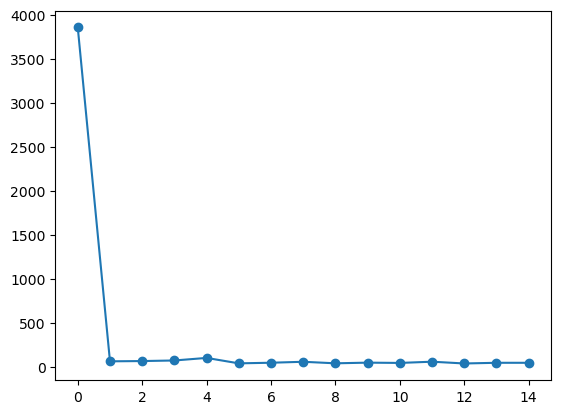

In [22]:
import matplotlib.pyplot as plt 

plt.plot(range(len(loss_values)), loss_values, marker = 'o')